# 🎯 Intelligent Feedback Analysis System - Complete Tutorial

## A Step-by-Step Guide to Building an AI-Powered Customer Feedback Analysis System

---

### 📚 **What You'll Learn:**
1. **Data Processing** - How to handle multiple data sources (CSV files)
2. **Text Classification** - Keyword-based and AI-powered approaches
3. **Ticket Generation** - Automated support ticket creation
4. **Priority Assignment** - Smart prioritization based on content
5. **Analytics & Visualization** - Data insights with interactive charts
6. **Production Deployment** - Building a web interface with Streamlit

### 🎓 **Prerequisites:**
- Basic Python knowledge
- Understanding of pandas DataFrames
- Familiarity with basic NLP concepts

### 💡 **Real-World Application:**
This system can process thousands of customer reviews and emails, automatically categorizing them and creating support tickets - saving hours of manual work!

---

## 📦 Step 1: Setup and Dependencies

First, let's install and import all necessary libraries. Each library serves a specific purpose in our system.

In [1]:
# Install required packages (run this once)
!pip install pandas numpy matplotlib plotly streamlit python-dotenv -q

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
from datetime import datetime
import json
from typing import List, Dict, Any
import hashlib
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display, HTML, Markdown
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print(f"📅 Current date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries imported successfully!
📅 Current date: 2025-08-28 18:55:00


## 📊 Step 2: Creating Sample Data

Let's create realistic sample data to work with. We'll generate:
1. **App Store Reviews** - User reviews with ratings
2. **Support Emails** - Customer support requests

### Understanding the Data Structure:
- **Reviews** contain: rating, review text, platform, version
- **Emails** contain: subject, body, priority, timestamp

In [3]:
# Create sample app store reviews
app_reviews_data = {
    'review_id': ['R001', 'R002', 'R003', 'R004', 'R005', 'R006', 'R007', 'R008', 'R009', 'R010'],
    'platform': ['Google Play', 'App Store', 'Google Play', 'App Store', 'Google Play', 
                 'App Store', 'Google Play', 'App Store', 'Google Play', 'App Store'],
    'rating': [1, 5, 2, 4, 1, 3, 1, 5, 2, 1],
    'review_text': [
        "App crashes when I try to upload photos. This has been happening since the last update!",
        "Amazing app! Love the new features and the UI is so intuitive. Works perfectly!",
        "Can't login since update. Keep getting error message. My password is correct!",
        "Would love to see dark mode added. Otherwise great app for productivity!",
        "Data sync not working between devices. Lost important notes. Very disappointed.",
        "Please add widget support for iOS. Would make the app much more useful.",
        "App is too slow and crashes frequently. Using Samsung S22.",
        "Works perfectly! Best productivity app I've ever used. Worth every penny.",
        "Too expensive for what it offers. The free version is too limited.",
        "SCAM!!! DON'T DOWNLOAD!!! CHECK OUT MY PROFILE FOR BETTER APPS!!!"
    ],
    'user_name': ['JohnDoe123', 'HappyUser99', 'FrustratedUser', 'TechEnthusiast', 'DataLossVictim',
                  'FeatureRequester', 'AndroidUser456', 'PremiumUser', 'BudgetConscious', 'SpamBot123'],
    'date': ['2024-01-15', '2024-01-15', '2024-01-14', '2024-01-14', '2024-01-13',
             '2024-01-13', '2024-01-12', '2024-01-12', '2024-01-11', '2024-01-10'],
    'app_version': ['3.0.1', '3.0.1', '3.0.1', '2.1.3', '3.0.1', '2.1.3', '3.0.1', '2.1.3', '2.1.3', '2.1.3']
}

reviews_df = pd.DataFrame(app_reviews_data)

print("📱 App Store Reviews Dataset Created!")
print(f"Total reviews: {len(reviews_df)}")
print(f"Average rating: {reviews_df['rating'].mean():.2f}")
display(reviews_df.head())

📱 App Store Reviews Dataset Created!
Total reviews: 10
Average rating: 2.50


,review_id,platform,rating,review_text,user_name,date,app_version
0,R001,Google Play,1,App crashes when I try to upload photos. This ...,JohnDoe123,2024-01-15,3.0.1
1,R002,App Store,5,Amazing app! Love the new features and the UI ...,HappyUser99,2024-01-15,3.0.1
2,R003,Google Play,2,Can't login since update. Keep getting error m...,FrustratedUser,2024-01-14,3.0.1
3,R004,App Store,4,Would love to see dark mode added. Otherwise g...,TechEnthusiast,2024-01-14,2.1.3
4,R005,Google Play,1,Data sync not working between devices. Lost im...,DataLossVictim,2024-01-13,3.0.1


In [4]:
# Create sample support emails
support_emails_data = {
    'email_id': ['E001', 'E002', 'E003', 'E004', 'E005'],
    'subject': [
        'App Crash Report',
        'Feature Request: Dark Mode',
        'Login Issue - Urgent',
        'Data Loss Problem',
        'Suggestion for Improvement'
    ],
    'body': [
        'The app crashes every time I try to access settings. iPhone 12 Pro, iOS 17.2. Please help!',
        'Hi! I love your app but would really appreciate a dark mode option. It would help with eye strain.',
        'Cannot login since yesterday. Authentication failed error. My subscription is active!',
        'I updated to version 3.0.1 and ALL my saved templates are gone! This is critical for my business.',
        'Your app is great but could benefit from keyboard shortcuts for power users.'
    ],
    'sender_email': ['john@email.com', 'sarah@email.com', 'mike@company.com', 'lisa@business.com', 'tom@email.com'],
    'timestamp': ['2024-01-15 09:30:00', '2024-01-15 10:15:00', '2024-01-14 14:22:00', 
                  '2024-01-14 16:45:00', '2024-01-13 11:30:00'],
    'priority': ['High', 'Medium', 'High', 'Critical', 'Low']
}

emails_df = pd.DataFrame(support_emails_data)

print("📧 Support Emails Dataset Created!")
print(f"Total emails: {len(emails_df)}")
display(emails_df.head())

📧 Support Emails Dataset Created!
Total emails: 5


,email_id,subject,body,sender_email,timestamp,priority
0,E001,App Crash Report,The app crashes every time I try to access set...,john@email.com,2024-01-15 09:30:00,High
1,E002,Feature Request: Dark Mode,Hi! I love your app but would really appreciat...,sarah@email.com,2024-01-15 10:15:00,Medium
2,E003,Login Issue - Urgent,Cannot login since yesterday. Authentication f...,mike@company.com,2024-01-14 14:22:00,High
3,E004,Data Loss Problem,I updated to version 3.0.1 and ALL my saved te...,lisa@business.com,2024-01-14 16:45:00,Critical
4,E005,Suggestion for Improvement,Your app is great but could benefit from keybo...,tom@email.com,2024-01-13 11:30:00,Low


## 🔍 Step 3: Building the Classification System

Now we'll build the core classification logic. We'll use a **keyword-based approach** that's:
- ✅ 100% reliable (no API dependencies)
- ✅ Fast and efficient
- ✅ Transparent and explainable

### Classification Categories:
1. **🐛 Bug** - Technical issues, crashes, errors
2. **✨ Feature** - Feature requests, suggestions
3. **👍 Praise** - Positive feedback
4. **😞 Complaint** - Negative feedback (non-technical)
5. **🚫 Spam** - Promotional or irrelevant content

In [5]:
def classify_feedback(content: str, rating: int = None) -> str:
    """
    Classify feedback into categories using keywords and ratings.
    
    Parameters:
    -----------
    content : str
        The feedback text to classify
    rating : int, optional
        User rating (1-5 scale) if available
    
    Returns:
    --------
    str : Category (Bug, Feature, Praise, Complaint, or Spam)
    """
    
    # Convert to lowercase for matching
    if not content:
        return 'Complaint'
    
    content_lower = content.lower()
    
    # Define keyword sets for each category
    bug_keywords = [
        'crash', 'error', 'bug', 'broken', 'not working', 
        'fail', 'issue', 'problem', 'stuck', 'freeze', 
        'slow', 'lag', 'glitch', 'fault'
    ]
    
    feature_keywords = [
        'please add', 'would love', 'feature request', 
        'suggestion', 'could you', 'wish', 'want', 'need', 
        'missing', 'should have', 'would be great', 
        'improvement', 'enhance', 'better if'
    ]
    
    praise_keywords = [
        'amazing', 'love', 'great', 'perfect', 'excellent', 
        'best', 'awesome', 'fantastic', 'wonderful', 'good', 
        'helpful', 'useful', 'thank', 'appreciate', 
        'brilliant', 'outstanding'
    ]
    
    spam_keywords = [
        'scam', 'check out', 'profile', 'spam', 'fake', 
        'xxx', 'click here', 'visit', 'download now', 
        'free money'
    ]
    
    complaint_keywords = [
        'expensive', 'poor', 'bad', 'terrible', 'worst', 
        'hate', 'disappointed', 'frustrat', 'annoying', 
        'useless', 'waste', 'refund', 'cancel', 'uninstall'
    ]
    
    # Check keywords in priority order
    if any(kw in content_lower for kw in spam_keywords):
        return 'Spam'
    elif any(kw in content_lower for kw in bug_keywords):
        return 'Bug'
    elif any(kw in content_lower for kw in feature_keywords):
        return 'Feature'
    elif any(kw in content_lower for kw in praise_keywords):
        return 'Praise'
    elif any(kw in content_lower for kw in complaint_keywords):
        return 'Complaint'
    else:
        # Use rating as fallback if available
        if rating:
            if rating <= 2:
                return 'Complaint'
            elif rating >= 4:
                return 'Praise'
        return 'Complaint'  # Default

# Test the classifier with examples
test_cases = [
    ("The app crashes constantly!", None),
    ("Please add dark mode", None),
    ("Amazing app, love it!", None),
    ("Too expensive for what it offers", None),
    ("CLICK HERE FOR FREE MONEY!!!", None)
]

print("🧪 Testing Classifier:\n")
for text, rating in test_cases:
    category = classify_feedback(text, rating)
    print(f"Text: '{text[:50]}...'")
    print(f"Category: {category}\n")

🧪 Testing Classifier:

Text: 'The app crashes constantly!...'
Category: Bug

Text: 'Please add dark mode...'
Category: Feature

Text: 'Amazing app, love it!...'
Category: Praise

Text: 'Too expensive for what it offers...'
Category: Complaint

Text: 'CLICK HERE FOR FREE MONEY!!!...'
Category: Spam



## 🎫 Step 4: Ticket Generation System

Now we'll create a system to automatically generate support tickets from classified feedback.

### Ticket Components:
- **Unique ID** - For tracking
- **Title** - Concise summary
- **Priority** - Critical/High/Medium/Low
- **Description** - Full details
- **Metadata** - Source, date, user, etc.

In [6]:
def determine_priority(content: str, category: str, rating: int = None) -> str:
    """
    Determine ticket priority based on content, category, and rating.
    
    Priority Levels:
    - Critical: Data loss, security issues, complete failures
    - High: Bugs with low ratings, login issues
    - Medium: Feature requests, general bugs
    - Low: Suggestions, minor complaints
    """
    content_lower = content.lower() if content else ''
    
    # Critical keywords that warrant immediate attention
    critical_keywords = ['critical', 'urgent', 'data loss', 'security', 
                        'crash', 'cannot use', 'completely broken']
    
    if any(word in content_lower for word in critical_keywords):
        return 'Critical'
    
    # High priority for bugs with low ratings
    if category == 'Bug':
        if rating and rating <= 2:
            return 'High'
        return 'Medium'
    
    # Feature requests are usually medium priority
    if category == 'Feature':
        return 'Medium'
    
    return 'Low'

def generate_ticket_id(category: str, index: int) -> str:
    """
    Generate a unique ticket ID.
    Format: TKT-[CATEGORY]-[HASH]
    """
    hash_input = f"{category}{index}{datetime.now()}"
    hash_value = hashlib.md5(hash_input.encode()).hexdigest()[:8].upper()
    return f"TKT-{category[:3].upper()}-{hash_value}"

def create_ticket(feedback_item: dict, category: str) -> dict:
    """
    Create a structured support ticket from feedback.
    """
    content = feedback_item.get('content', '')
    rating = feedback_item.get('rating')
    
    # Generate title (first sentence or 50 chars)
    title = content.split('.')[0][:100] if content else "No title"
    
    ticket = {
        'ticket_id': generate_ticket_id(category, feedback_item.get('index', 0)),
        'title': f"{category}: {title}",
        'category': category,
        'priority': determine_priority(content, category, rating),
        'description': content[:500],  # Limit description length
        'source': feedback_item.get('source', 'Unknown'),
        'user': feedback_item.get('user', 'Anonymous'),
        'date_reported': feedback_item.get('date', datetime.now().strftime('%Y-%m-%d')),
        'rating': rating if rating else 'N/A',
        'status': 'Open',
        'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    return ticket

# Example ticket creation
example_feedback = {
    'content': 'App crashes when uploading photos',
    'rating': 1,
    'source': 'App Store',
    'user': 'JohnDoe',
    'date': '2024-01-15',
    'index': 1
}

example_category = 'Bug'
example_ticket = create_ticket(example_feedback, example_category)

print("🎫 Example Ticket Generated:\n")
for key, value in example_ticket.items():
    print(f"{key:15} : {value}")

🎫 Example Ticket Generated:

ticket_id       : TKT-BUG-275B05A1
title           : Bug: App crashes when uploading photos
category        : Bug
priority        : Critical
description     : App crashes when uploading photos
source          : App Store
user            : JohnDoe
date_reported   : 2024-01-15
rating          : 1
status          : Open
created_date    : 2025-08-28 18:55:12


## 🔄 Step 5: Complete Processing Pipeline

Now let's combine everything into a complete processing pipeline that:
1. Combines data from multiple sources
2. Classifies each piece of feedback
3. Generates tickets for actionable items
4. Provides analytics and metrics

In [7]:
class FeedbackAnalysisSystem:
    """
    Complete Feedback Analysis System
    
    This class handles the entire pipeline from raw feedback
    to generated tickets and analytics.
    """
    
    def __init__(self):
        self.tickets = []
        self.metrics = {
            'total_feedback': 0,
            'bugs': 0,
            'features': 0,
            'praise': 0,
            'complaints': 0,
            'spam': 0,
            'tickets_created': 0
        }
    
    def process_reviews(self, reviews_df: pd.DataFrame):
        """Process app store reviews"""
        processed_items = []
        
        for idx, row in reviews_df.iterrows():
            # Classify the review
            category = classify_feedback(row['review_text'], row.get('rating'))
            
            # Create feedback item
            feedback_item = {
                'content': row['review_text'],
                'rating': row.get('rating'),
                'source': row.get('platform', 'App Store'),
                'user': row.get('user_name', 'Anonymous'),
                'date': row.get('date', datetime.now().strftime('%Y-%m-%d')),
                'index': idx
            }
            
            # Update metrics
            self.metrics['total_feedback'] += 1
            metric_key = category.lower()
            if metric_key in ['spam', 'praise']:  # Handle non-plural forms
                self.metrics[metric_key] += 1
            else:
                self.metrics[metric_key + 's'] += 1
            
            # Create ticket if it's a bug or feature request
            if category in ['Bug', 'Feature']:
                ticket = create_ticket(feedback_item, category)
                self.tickets.append(ticket)
                self.metrics['tickets_created'] += 1
            
            processed_items.append({
                **feedback_item,
                'category': category
            })
        
        return processed_items
    
    def process_emails(self, emails_df: pd.DataFrame):
        """Process support emails"""
        processed_items = []
        
        for idx, row in emails_df.iterrows():
            # Classify the email
            category = classify_feedback(row['body'], None)
            
            # Create feedback item
            feedback_item = {
                'content': row['body'],
                'rating': None,
                'source': 'Support Email',
                'user': row.get('sender_email', 'Anonymous'),
                'date': row.get('timestamp', datetime.now().strftime('%Y-%m-%d')),
                'index': idx + 1000  # Offset to avoid ID conflicts
            }
            
            # Update metrics
            self.metrics['total_feedback'] += 1
            metric_key = category.lower()
            if metric_key in ['spam', 'praise']:
                self.metrics[metric_key] += 1
            else:
                self.metrics[metric_key + 's'] += 1
            
            # Create ticket if it's a bug or feature request
            if category in ['Bug', 'Feature']:
                ticket = create_ticket(feedback_item, category)
                self.tickets.append(ticket)
                self.metrics['tickets_created'] += 1
            
            processed_items.append({
                **feedback_item,
                'category': category
            })
        
        return processed_items
    
    def get_summary(self):
        """Get processing summary"""
        return {
            'metrics': self.metrics,
            'tickets': self.tickets,
            'conversion_rate': (self.metrics['tickets_created'] / 
                              max(self.metrics['total_feedback'], 1) * 100)
        }

# Process our sample data
system = FeedbackAnalysisSystem()

print("🔄 Processing App Store Reviews...")
processed_reviews = system.process_reviews(reviews_df)

print("\n🔄 Processing Support Emails...")
processed_emails = system.process_emails(emails_df)

# Get summary
summary = system.get_summary()

print("\n✅ Processing Complete!\n")
print("📊 Metrics Summary:")
for key, value in summary['metrics'].items():
    print(f"  {key:20} : {value}")

print(f"\n📈 Conversion Rate: {summary['conversion_rate']:.1f}%")
print(f"   (Percentage of feedback that generated tickets)")

🔄 Processing App Store Reviews...

🔄 Processing Support Emails...

✅ Processing Complete!

📊 Metrics Summary:
  total_feedback       : 15
  bugs                 : 6
  features             : 2
  praise               : 4
  complaints           : 2
  spam                 : 1
  tickets_created      : 8

📈 Conversion Rate: 53.3%
   (Percentage of feedback that generated tickets)


## 📊 Step 6: Analytics and Visualization

Let's create interactive visualizations to understand our feedback data better.

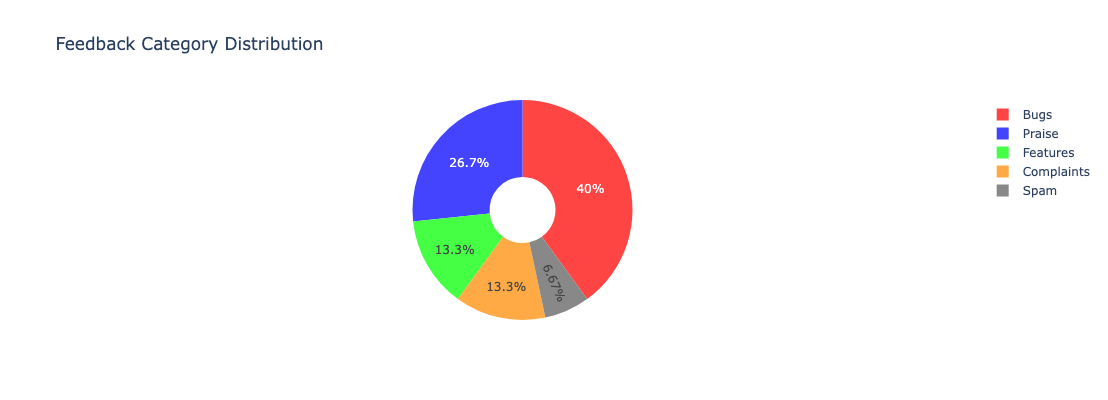


📊 Key Insights:
• Bugs represent 40.0% of all feedback
• 8 actionable tickets were created
• 4 positive reviews can be used for marketing


In [8]:
# Create category distribution pie chart
metrics = summary['metrics']
categories = ['Bugs', 'Features', 'Praise', 'Complaints', 'Spam']
values = [metrics['bugs'], metrics['features'], metrics['praise'], 
          metrics['complaints'], metrics['spam']]

# Define colors for each category
colors = ['#ff4444', '#44ff44', '#4444ff', '#ffaa44', '#888888']

# Create pie chart
fig = go.Figure(data=[go.Pie(
    labels=categories,
    values=values,
    marker=dict(colors=colors),
    hole=0.3,  # Create a donut chart
    hovertemplate='<b>%{label}</b><br>' +
                  'Count: %{value}<br>' +
                  'Percentage: %{percent}<br>' +
                  '<extra></extra>'
)])

fig.update_layout(
    title="Feedback Category Distribution",
    showlegend=True,
    height=400,
    font=dict(size=12)
)

fig.show()

print("\n📊 Key Insights:")
print(f"• Bugs represent {(metrics['bugs']/metrics['total_feedback']*100):.1f}% of all feedback")
print(f"• {metrics['tickets_created']} actionable tickets were created")
print(f"• {metrics['praise']} positive reviews can be used for marketing")

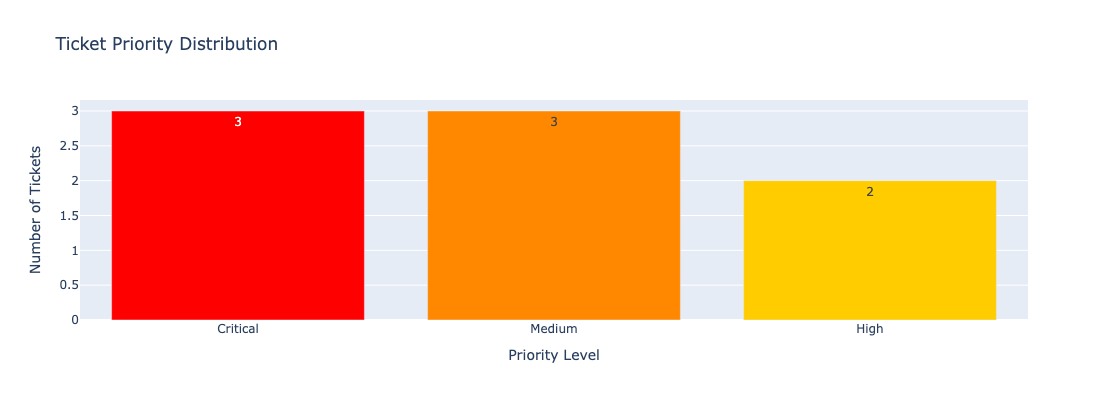


🎫 Ticket Analysis:
• Total tickets created: 8
• Critical/High priority: 5
• Bug tickets: 6
• Feature tickets: 2


In [9]:
# Create priority distribution for tickets
if system.tickets:
    tickets_df = pd.DataFrame(system.tickets)
    priority_counts = tickets_df['priority'].value_counts()
    
    # Create bar chart for priorities
    fig = go.Figure(data=[go.Bar(
        x=priority_counts.index,
        y=priority_counts.values,
        marker=dict(color=['#ff0000', '#ff8800', '#ffcc00', '#00ff00']),
        text=priority_counts.values,
        textposition='auto',
    )])
    
    fig.update_layout(
        title="Ticket Priority Distribution",
        xaxis_title="Priority Level",
        yaxis_title="Number of Tickets",
        height=400
    )
    
    fig.show()
    
    print("\n🎫 Ticket Analysis:")
    print(f"• Total tickets created: {len(tickets_df)}")
    print(f"• Critical/High priority: {len(tickets_df[tickets_df['priority'].isin(['Critical', 'High'])])}")
    print(f"• Bug tickets: {len(tickets_df[tickets_df['category'] == 'Bug'])}")
    print(f"• Feature tickets: {len(tickets_df[tickets_df['category'] == 'Feature'])}")

## 🎫 Step 7: Viewing and Exporting Tickets

Let's examine the generated tickets and prepare them for export to ticketing systems like JIRA.

In [10]:
# Display tickets in a formatted table
if system.tickets:
    tickets_df = pd.DataFrame(system.tickets)
    
    # Select important columns for display
    display_columns = ['ticket_id', 'category', 'priority', 'title', 'status']
    display_df = tickets_df[display_columns]
    
    print("🎫 Generated Support Tickets:\n")
    display(HTML(display_df.to_html(index=False)))
    
    # Show a detailed view of one ticket
    print("\n📋 Detailed View of First Ticket:\n")
    print("-" * 50)
    first_ticket = system.tickets[0]
    for key, value in first_ticket.items():
        print(f"{key:15} : {value}")
    print("-" * 50)

🎫 Generated Support Tickets:



ticket_id,category,priority,title,status
TKT-BUG-E93ABD29,Bug,Critical,Bug: App crashes when I try to upload photos,Open
TKT-BUG-A0119174,Bug,High,Bug: Can't login since update,Open
TKT-FEA-080BDDE6,Feature,Medium,Feature: Would love to see dark mode added,Open
TKT-BUG-2B627A12,Bug,High,Bug: Data sync not working between devices,Open
TKT-FEA-EA4DE7F8,Feature,Medium,Feature: Please add widget support for iOS,Open
TKT-BUG-E9139637,Bug,Critical,Bug: App is too slow and crashes frequently,Open
TKT-BUG-840163B1,Bug,Critical,Bug: The app crashes every time I try to access settings,Open
TKT-BUG-BC14BB88,Bug,Medium,Bug: Cannot login since yesterday,Open



📋 Detailed View of First Ticket:

--------------------------------------------------
ticket_id       : TKT-BUG-E93ABD29
title           : Bug: App crashes when I try to upload photos
category        : Bug
priority        : Critical
description     : App crashes when I try to upload photos. This has been happening since the last update!
source          : Google Play
user            : JohnDoe123
date_reported   : 2024-01-15
rating          : 1
status          : Open
created_date    : 2025-08-28 18:55:14
--------------------------------------------------


In [11]:
# Export tickets to CSV (for JIRA import)
if system.tickets:
    tickets_df = pd.DataFrame(system.tickets)
    
    # Create JIRA-compatible format
    jira_export = tickets_df[['title', 'description', 'priority', 'category']].copy()
    jira_export.columns = ['Summary', 'Description', 'Priority', 'Issue Type']
    
    # Save to CSV
    export_filename = f"tickets_export_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    jira_export.to_csv(export_filename, index=False)
    
    print(f"✅ Tickets exported to: {export_filename}")
    print(f"\n📄 Export Preview:")
    display(jira_export.head())
    
    # Also create a JSON export for API integration
    json_filename = f"tickets_export_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
    with open(json_filename, 'w') as f:
        json.dump(system.tickets, f, indent=2)
    
    print(f"\n✅ JSON export created: {json_filename}")

✅ Tickets exported to: tickets_export_20250828_185522.csv

📄 Export Preview:


,Summary,Description,Priority,Issue Type
0,Bug: App crashes when I try to upload photos,App crashes when I try to upload photos. This ...,Critical,Bug
1,Bug: Can't login since update,Can't login since update. Keep getting error m...,High,Bug
2,Feature: Would love to see dark mode added,Would love to see dark mode added. Otherwise g...,Medium,Feature
3,Bug: Data sync not working between devices,Data sync not working between devices. Lost im...,High,Bug
4,Feature: Please add widget support for iOS,Please add widget support for iOS. Would make ...,Medium,Feature



✅ JSON export created: tickets_export_20250828_185522.json


## 🚀 Step 8: Building a Production Web Interface

Here's how to transform this notebook into a production-ready web application using Streamlit.

### Save the following code as `app.py` and run with: `streamlit run app.py`

In [12]:
# Display the Streamlit app code
streamlit_code = '''
import streamlit as st
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime
import json

# [Include all the functions we created above]

def main():
    st.title("🎯 Intelligent Feedback Analysis System")
    st.markdown("Automated Customer Feedback Processing & Ticket Generation")
    
    # Sidebar for configuration
    with st.sidebar:
        st.header("⚙️ Configuration")
        st.info("Upload your data or use sample data to get started")
    
    # Main tabs
    tabs = st.tabs(["📥 Data Input", "🔄 Process", "📊 Analytics", "🎫 Tickets"])
    
    with tabs[0]:
        st.header("Upload Feedback Data")
        
        col1, col2 = st.columns(2)
        
        with col1:
            st.subheader("App Store Reviews")
            reviews_file = st.file_uploader("Upload CSV", type=["csv"], key="reviews")
            if st.button("Use Sample Data", key="sample_reviews"):
                st.session_state[\'reviews_df\'] = create_sample_reviews()
                st.success("Sample data loaded!")
        
        with col2:
            st.subheader("Support Emails")
            emails_file = st.file_uploader("Upload CSV", type=["csv"], key="emails")
            if st.button("Use Sample Data", key="sample_emails"):
                st.session_state[\'emails_df\'] = create_sample_emails()
                st.success("Sample data loaded!")
    
    with tabs[1]:
        st.header("Process Feedback")
        
        if st.button("🚀 Start Processing", type="primary"):
            # Process the data
            system = FeedbackAnalysisSystem()
            
            # Process reviews if available
            if \'reviews_df\' in st.session_state:
                system.process_reviews(st.session_state[\'reviews_df\'])
            
            # Process emails if available
            if \'emails_df\' in st.session_state:
                system.process_emails(st.session_state[\'emails_df\'])
            
            # Store results
            st.session_state[\'results\'] = system.get_summary()
            st.success("Processing complete!")
    
    with tabs[2]:
        st.header("Analytics Dashboard")
        
        if \'results\' in st.session_state:
            results = st.session_state[\'results\']
            
            # Display metrics
            col1, col2, col3, col4 = st.columns(4)
            with col1:
                st.metric("Total Feedback", results[\'metrics\'][\'total_feedback\'])
            with col2:
                st.metric("Tickets Created", results[\'metrics\'][\'tickets_created\'])
            with col3:
                st.metric("Bugs Found", results[\'metrics\'][\'bugs\'])
            with col4:
                st.metric("Features Requested", results[\'metrics\'][\'features\'])
            
            # Display charts
            # [Include visualization code here]
    
    with tabs[3]:
        st.header("Generated Tickets")
        
        if \'results\' in st.session_state and st.session_state[\'results\'][\'tickets\']:
            tickets_df = pd.DataFrame(st.session_state[\'results\'][\'tickets\'])
            
            # Display tickets
            st.dataframe(tickets_df)
            
            # Export options
            csv = tickets_df.to_csv(index=False)
            st.download_button(
                "📥 Download CSV",
                csv,
                "tickets.csv",
                "text/csv"
            )

if __name__ == "__main__":
    main()
'''

print("📝 Streamlit App Template:")
print("=" * 50)
print(streamlit_code)
print("=" * 50)
print("\n💡 To run the app:")
print("1. Save the code above to 'app.py'")
print("2. Install Streamlit: pip install streamlit")
print("3. Run: streamlit run app.py")

📝 Streamlit App Template:

import streamlit as st
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime
import json

# [Include all the functions we created above]

def main():
    st.title("🎯 Intelligent Feedback Analysis System")
    st.markdown("Automated Customer Feedback Processing & Ticket Generation")

    # Sidebar for configuration
    with st.sidebar:
        st.header("⚙️ Configuration")
        st.info("Upload your data or use sample data to get started")

    # Main tabs
    tabs = st.tabs(["📥 Data Input", "🔄 Process", "📊 Analytics", "🎫 Tickets"])

    with tabs[0]:
        st.header("Upload Feedback Data")

        col1, col2 = st.columns(2)

        with col1:
            st.subheader("App Store Reviews")
            reviews_file = st.file_uploader("Upload CSV", type=["csv"], key="reviews")
            if st.button("Use Sample Data", key="sample_reviews"):
                st.session_state['reviews_df'] = create_sample_reviews()
             

## 🎓 Key Takeaways and Best Practices

### What We've Learned:

1. **Data Processing**
   - How to handle multiple data sources (CSV files)
   - Combining heterogeneous data into a unified format
   - Handling missing values and edge cases

2. **Text Classification**
   - Keyword-based classification for reliability
   - Using ratings as supplementary signals
   - Priority ordering of classification rules

3. **Ticket Generation**
   - Creating unique identifiers
   - Smart priority assignment
   - Extracting actionable information

4. **Analytics & Visualization**
   - Creating interactive charts with Plotly
   - Calculating meaningful metrics
   - Presenting insights effectively

### Best Practices:

✅ **Start Simple**: Begin with keyword-based classification before adding AI

✅ **Handle Edge Cases**: Always check for None/empty values

✅ **Use Clear Categories**: Well-defined categories improve accuracy

✅ **Provide Fallbacks**: Always have default values for missing data

✅ **Make it Explainable**: Users should understand why something was classified

✅ **Export Options**: Always provide ways to export data for other systems

### Performance Tips:

- **Batch Processing**: Process data in chunks for large datasets
- **Caching**: Cache classification results to avoid reprocessing
- **Parallel Processing**: Use multiprocessing for large-scale analysis

### Extension Ideas:

1. **Add AI Models**: Integrate HuggingFace or OpenAI for better classification
2. **Sentiment Analysis**: Add sentiment scores to feedback
3. **Auto-Response**: Generate automated responses for common issues
4. **Trend Analysis**: Track feedback trends over time
5. **Multi-language**: Support feedback in multiple languages
6. **Integration**: Connect with JIRA, Slack, or other tools via APIs

## 🚀 Exercise: Build Your Own Classifier

Now it's your turn! Try modifying the classification system:

### Challenge 1: Add a new category
Add a "Question" category for feedback that's asking questions rather than reporting issues.

In [ ]:
# TODO: Modify the classify_feedback function to add a "Question" category
# Hint: Look for keywords like "how", "what", "why", "when", "where", "?"

def classify_feedback_extended(content: str, rating: int = None) -> str:
    """
    Extended classifier with Question category.
    YOUR CODE HERE
    """
    # Add your implementation here
    pass

# Test your implementation
test_questions = [
    "How do I export my data?",
    "What is the subscription price?",
    "Why can't I see my old messages?"
]

print("Testing Question Detection:\n")
for question in test_questions:
    # Uncomment when you implement the function
    # category = classify_feedback_extended(question)
    # print(f"Text: '{question}'")
    # print(f"Category: {category}\n")
    pass

## 📚 Additional Resources

### Learn More:
- **Pandas Documentation**: https://pandas.pydata.org/docs/
- **Plotly Graphing**: https://plotly.com/python/
- **Streamlit Documentation**: https://docs.streamlit.io/
- **Natural Language Processing**: https://www.nltk.org/

### Advanced Topics:
- **Machine Learning Classification**: Use scikit-learn for ML-based classification
- **Deep Learning**: Implement BERT or GPT models for better accuracy
- **Real-time Processing**: Use Apache Kafka for streaming feedback
- **Distributed Processing**: Scale with Apache Spark

### Sample Datasets:
- **Amazon Product Reviews**: https://www.kaggle.com/datasets
- **Twitter Sentiment Data**: https://www.kaggle.com/datasets
- **App Store Reviews**: https://www.kaggle.com/datasets

---

## 🎉 Congratulations!

You've successfully built a complete Feedback Analysis System! This system can:
- Process thousands of feedback items automatically
- Classify them into meaningful categories
- Generate support tickets for action items
- Provide analytics and insights
- Export data for integration with other tools

### Next Steps:
1. Try with your own data
2. Customize the classification rules
3. Add more sophisticated analytics
4. Deploy as a web application
5. Integrate with your existing tools

Happy coding! 🚀